In [2]:
%load_ext autoreload
%autoreload 2
# All auxiliary code is in ../src
import sys

sys.path.append("../../src/")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
from classification_utility import train_test_for_non_distance_comp


_, _, _, test_labels = train_test_for_non_distance_comp()

Mapping of geo area: {'Africa': 0, 'America': 1, 'Asia': 2, 'Eastern Europe': 3, 'Northern Europe': 4, 'Oceania': 5, 'Southern Europe': 6, 'Western Europe': 7}


## Model comparison

In [21]:
from classification_utility import load_classification_res


_, _, knn_smote_predicted_labels, knn_smote_probability_class_res = load_classification_res('knn_smote_sampling')
_, _, linear_svm_under_predicted_labels, linear_svm_under_probability_class_res = load_classification_res('linear_svm_under_sampling')
_, _, rbf_svm_under_predicted_labels, rbf_svm_under_probability_class_res = load_classification_res('rbf_svm_under_sampling')
_, _, ripper_under_predicted_labels, ripper_under_probability_class_res = load_classification_res('ripper_under_sampling')

_, _, dt_under_sampling_predicted_labels, results_dt_under_sampling = load_classification_res('dt_under_sampling')
_, _, rf_over_sampling_predicted_labels, results_rf_over_sampling = load_classification_res('rf_over_sampling')
_, _, abc_under_sampling_predicted_labels, results_abc_under_sampling = load_classification_res('ada_under_sampling')
_, _, gnb_smote_sampling_predicted_labels, results_gnb_smote_sampling = load_classification_res('gnb_smote_sampling')

_, _, nn_under_predicted_labels, nn_under_probability_class_res = load_classification_res('NN_under_sampling')

### ROC e PR curve comparison

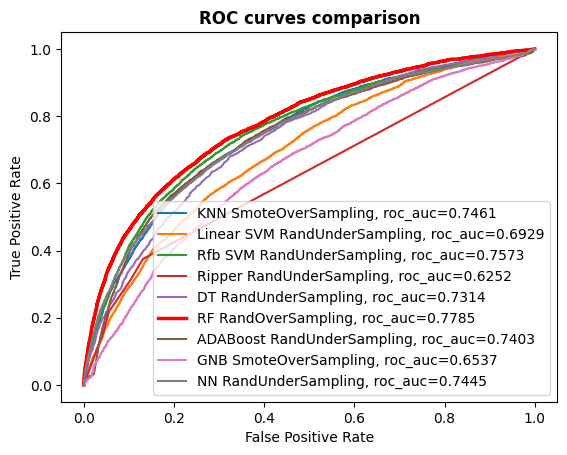

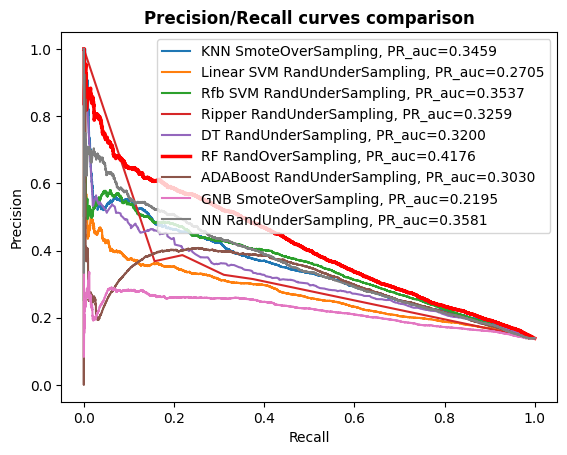

In [22]:
from classification_utility import compare_roc_curves, compare_pr_curves

curves = [
    (knn_smote_probability_class_res, "KNN SmoteOverSampling"),
    (linear_svm_under_probability_class_res, "Linear SVM RandUnderSampling"),
    (rbf_svm_under_probability_class_res, "Rfb SVM RandUnderSampling"),
    (ripper_under_probability_class_res, "Ripper RandUnderSampling"),
    (results_dt_under_sampling, "DT RandUnderSampling"),
    (results_rf_over_sampling, "RF RandOverSampling"),
    (results_abc_under_sampling, "ADABoost RandUnderSampling"),
    (results_gnb_smote_sampling, "GNB SmoteOverSampling"),
    (nn_under_probability_class_res, "NN RandUnderSampling")
]
compare_roc_curves(curves, title="ROC curves comparison")
compare_pr_curves(curves, title="Precision/Recall curves comparison")

### F1 macro model comparison

In [23]:
class ModelInfo:
    def __init__(self, name):
        self.name = name

In [26]:
from classification_utility import compare_f1_score

test_predictions = [
    (knn_smote_predicted_labels, ModelInfo("KNN smote")),
    (linear_svm_under_predicted_labels, ModelInfo("Linear SVM under sampling")),
    (rbf_svm_under_predicted_labels, ModelInfo("Rfb SVM under sampling")),
    (ripper_under_predicted_labels, ModelInfo("Ripper under sampling")),
    (dt_under_sampling_predicted_labels, ModelInfo("DT UnderSampling")),
    (rf_over_sampling_predicted_labels, ModelInfo("RF OverSampling")),
    (abc_under_sampling_predicted_labels, ModelInfo("ADABoost UnderSampling")),
    (gnb_smote_sampling_predicted_labels, ModelInfo("GNB Smote OverSampling")),
    (nn_under_predicted_labels, ModelInfo("NN UnderSampling"))
]
model_infos = [model_info for _, model_info in test_predictions]
model_predictions = [predictions for predictions, _ in test_predictions]
compare_f1_score(model_infos, model_predictions, test_labels)

,Model,Macro F1-Score
5,RF OverSampling,0.675041
2,Rfb SVM under sampling,0.640850
8,NN UnderSampling,0.638565
0,KNN smote,0.637014
6,ADABoost UnderSampling,0.618663
4,DT UnderSampling,0.618055
3,Ripper under sampling,0.612331
1,Linear SVM under sampling,0.591383
7,GNB Smote OverSampling,0.575733
